<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
#!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-10-27 17:58:35--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  55.1MB/s    in 3.6s    

2025-10-27 17:58:39 (55.3 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [1]:
#!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 104.3 MB/s eta 0:00:00


In [2]:
#!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 142.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 142.7 MB/s eta 0:00:00


In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import textwrap

#### Connect to the SQLite database


In [3]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [4]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [5]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [6]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [7]:
QUERY = " SELECT CompTotal FROM main"
df_ct = pd.read_sql_query(QUERY, conn)
df_ct[['CompTotal']].isnull().mean()

CompTotal    0.48439
dtype: float64

+++we see that we have 48,44% of rows with missing value for this column; these rows will be automatically excluded from the histogram by the plotting method, but it is important to let it on the record!

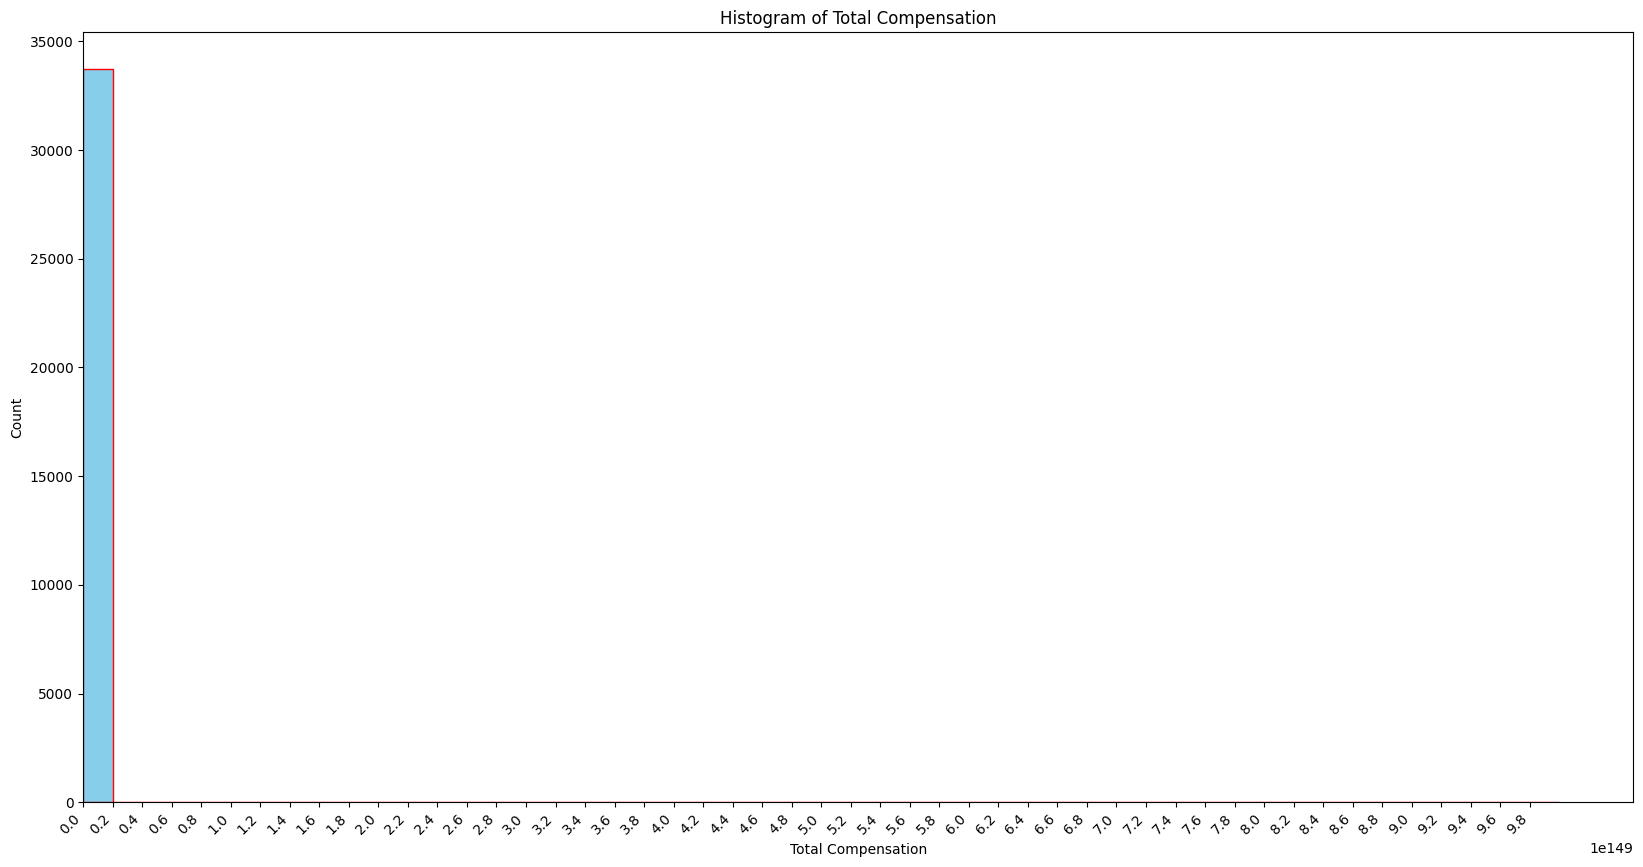

In [8]:
#plotting the histogram
plt.figure(figsize=(20, 10))
# Using plt.hist to create the histogram
# Setting the number of bins to 50 for better visualization
counts, bins, patches = plt.hist(df_ct['CompTotal'], bins=50, color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Total Compensation')
plt.ylabel('Count')
plt.title('Histogram of Total Compensation')
plt.xlim(left=0)
plt.show()

+++Looking at this histogram, we see that the range of this variable is quite large, we would have to deal with outliers for a better analysis. Additionally, the currency is not the same for all rows, they are relative to the countries. I think that to analyze compensation we should use the ConvertedCompYearly variable, which has the compensation values converted to US dollars for all rows, dealing with outliers for a better analysis. We have done this in the 'Normalizing data' lab, so I will not repeat it here.

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [9]:
#let's get a specific data set for this, dropping the rows with missing values
QUERY = "SELECT YearsCodePro FROM main WHERE YearsCodePro IS NOT NULL"
df_ycp = pd.read_sql_query(QUERY, conn)
df_ycp['YearsCodePro'].unique()

array(['17', '27', '7', '11', '25', '12', '10', '3', 'Less than 1 year',
       '18', '37', '15', '20', '6', '2', '16', '8', '14', '4', '45', '1',
       '24', '29', '5', '30', '26', '9', '33', '13', '35', '23', '22',
       '31', '19', '21', '28', '34', '32', '40', '50', '39', '44', '42',
       '41', '36', '38', 'More than 50 years', '43', '47', '48', '46',
       '49'], dtype=object)

In [10]:
#let's convert YearsCodePro to numeric
mapping = {'Less than 1 year': 0.0, 'More than 50 years': 50.0}
df_ycp['YearsCodePro'] = df_ycp['YearsCodePro'].replace(mapping).astype(float)
print(df_ycp['YearsCodePro'].unique())
df_ycp.head()

[17. 27.  7. 11. 25. 12. 10.  3.  0. 18. 37. 15. 20.  6.  2. 16.  8. 14.
  4. 45.  1. 24. 29.  5. 30. 26.  9. 33. 13. 35. 23. 22. 31. 19. 21. 28.
 34. 32. 40. 50. 39. 44. 42. 41. 36. 38. 43. 47. 48. 46. 49.]


,YearsCodePro
0,17.0
1,27.0
2,7.0
3,11.0
4,25.0


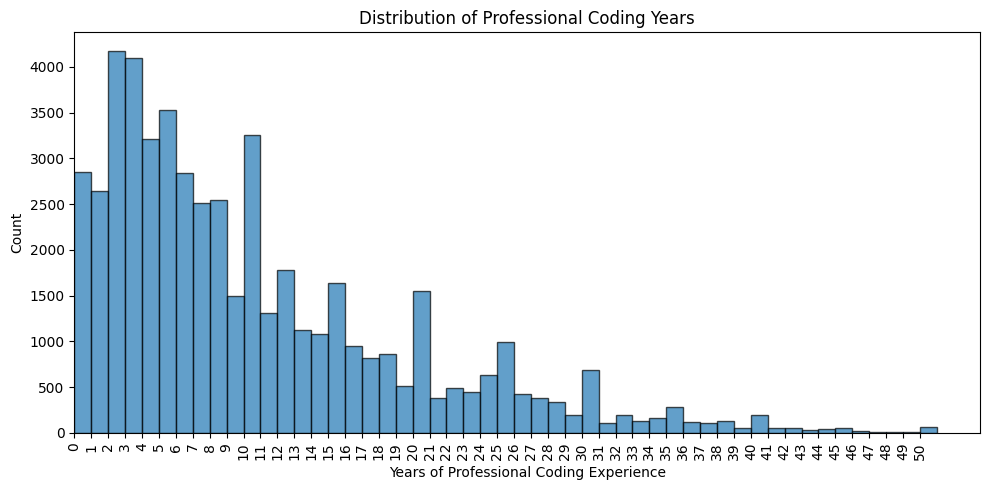

In [13]:
#plotting the histogram

values = df_ycp['YearsCodePro']

# get sorted unique values
unique_values = np.sort(values.unique())

# plot histogram with bins at unique values
plt.figure(figsize=(10, 5))
plt.hist(values, bins=np.append(unique_values, unique_values[-1] + 1), edgecolor='black', alpha=0.7)
plt.xlim(left=0)
plt.xticks(unique_values, rotation=90)  # show all values on x-axis
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Count')
plt.title('Distribution of Professional Coding Years')
plt.tight_layout()
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


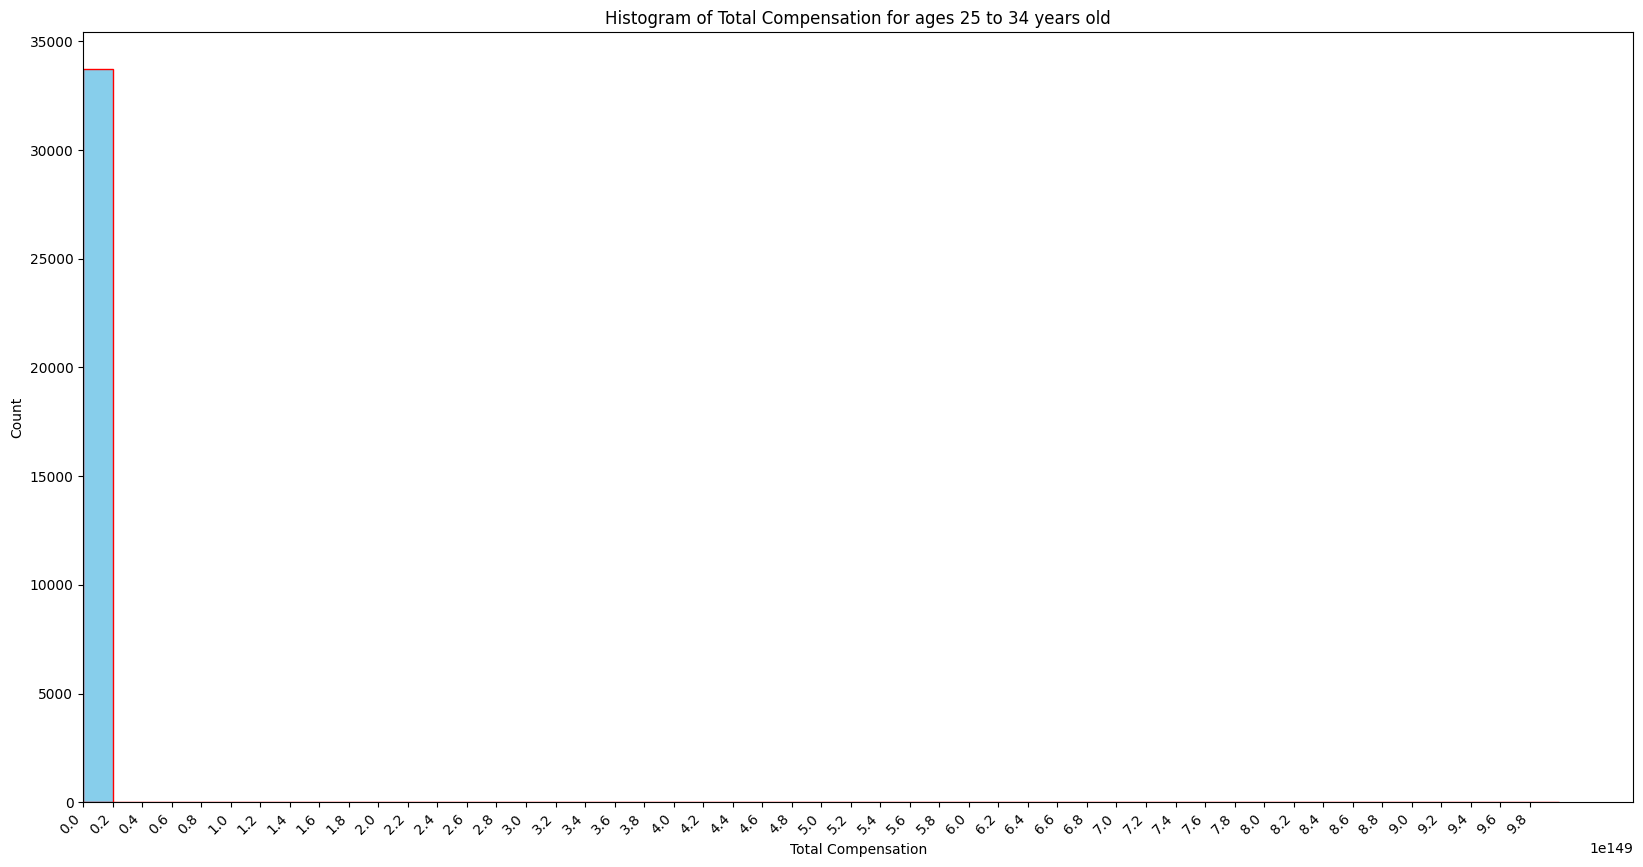

In [14]:
#Histogram for the age range '25-34 years old'
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL AND Age = '25-34 years old'"
df_ct_25_34 = pd.read_sql_query(QUERY, conn)
#plotting the histogram
plt.figure(figsize=(20, 10))
# Using plt.hist to create the histogram
# Setting the number of bins to 50 for better visualization
counts, bins, patches = plt.hist(df_ct['CompTotal'], bins=50, color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Total Compensation')
plt.ylabel('Count')
plt.title('Histogram of Total Compensation for ages 25 to 34 years old')
plt.xlim(left=0)
plt.show()

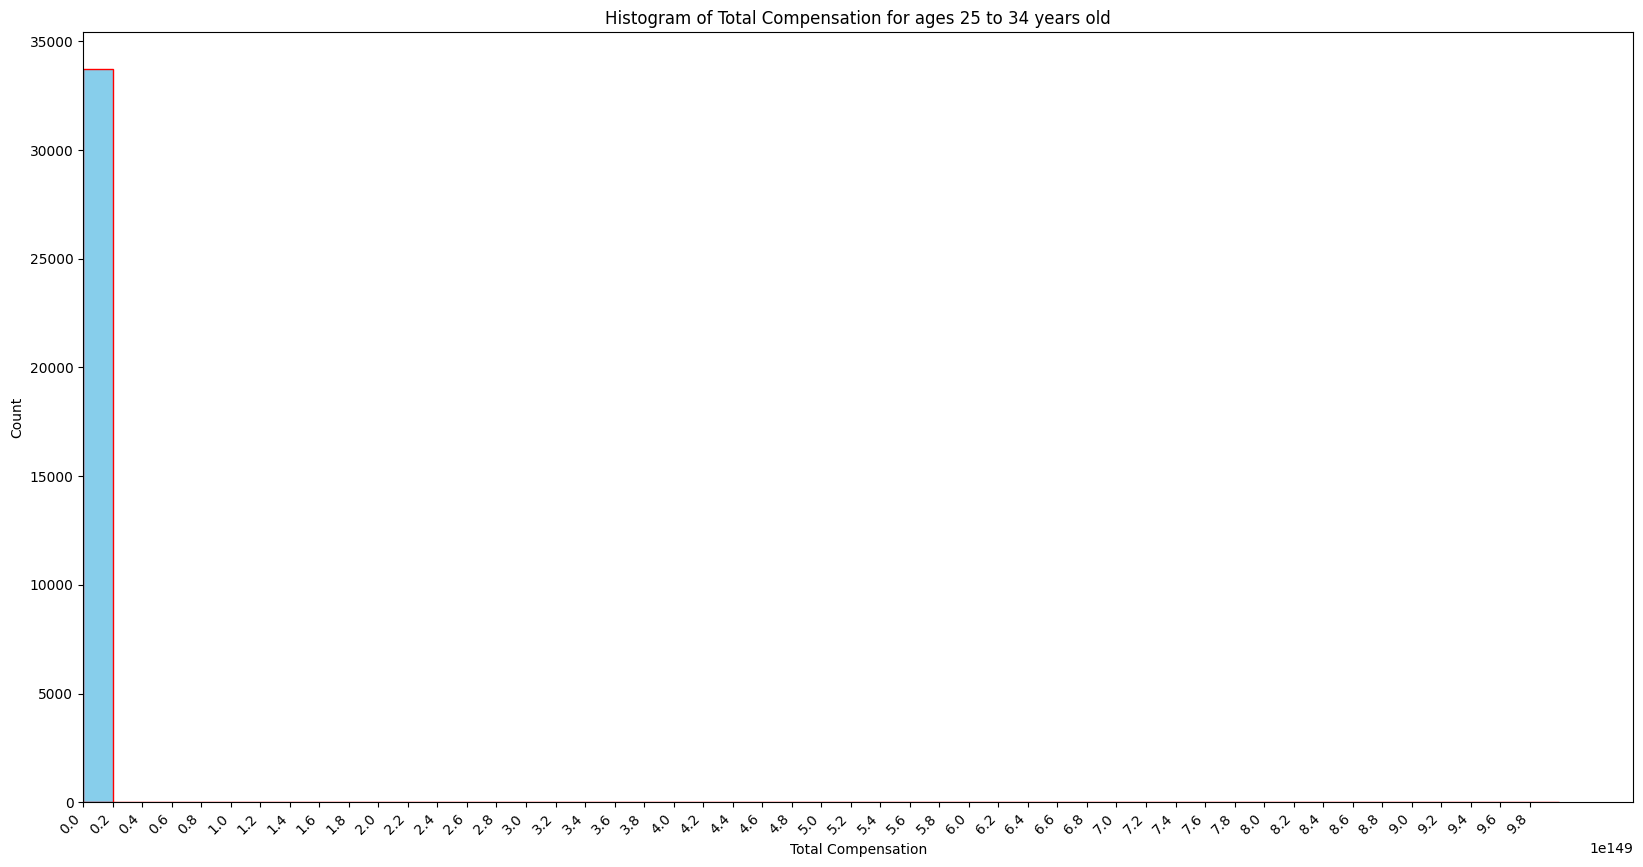

In [15]:
#Histogram for the age range '35-44 years old'
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL AND Age = '35-44 years old'"
df_ct_35_44 = pd.read_sql_query(QUERY, conn)
#plotting the histogram
plt.figure(figsize=(20, 10))
# Using plt.hist to create the histogram
# Setting the number of bins to 50 for better visualization
counts, bins, patches = plt.hist(df_ct['CompTotal'], bins=50, color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Total Compensation')
plt.ylabel('Count')
plt.title('Histogram of Total Compensation for ages 25 to 34 years old')
plt.xlim(left=0)
plt.show()

In [16]:
#because of outliers, we cannot see much difference, cannot do a good analysis
#let's see how it looks eliminating outliers outside the limits of 1.5 IQR
QUERY = "SELECT CompTotal, Age FROM main WHERE CompTotal IS NOT NULL"
df_ct = pd.read_sql_query(QUERY, conn)
print(df_ct.describe())
df_ct.head()

           CompTotal
count   3.374000e+04
mean   2.963841e+145
std    5.444117e+147
min     0.000000e+00
25%     6.000000e+04
50%     1.100000e+05
75%     2.500000e+05
max    1.000000e+150


,CompTotal,Age
0,2040000.0,18-24 years old
1,28000.0,25-34 years old
2,85000.0,35-44 years old
3,50000.0,35-44 years old
4,110000.0,25-34 years old


In [17]:
#let's calculate the interquartile range for df_ct['CompTotal'] using the values produced by describe() (Q3  and Q1)
q3 = 2.500000e+05
q1 = 6.000000e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)

IQR =  190000.0
Upper bound for outliers =  535000.0
Lower bound for outliers =  -225000.0


+++As the minimum value is zero, we do not have to worry about the lower bound

In [18]:
df_ct_no_out = df_ct[df_ct['CompTotal'] <= 535000.0]
print(df_ct_no_out.describe())
df_ct_no_out.head()

           CompTotal
count   27864.000000
mean   117182.605369
std     99970.300622
min         0.000000
25%     50000.000000
50%     88000.000000
75%    150000.000000
max    535000.000000


,CompTotal,Age
1,28000.0,25-34 years old
2,85000.0,35-44 years old
3,50000.0,35-44 years old
4,110000.0,25-34 years old
5,126420.0,35-44 years old


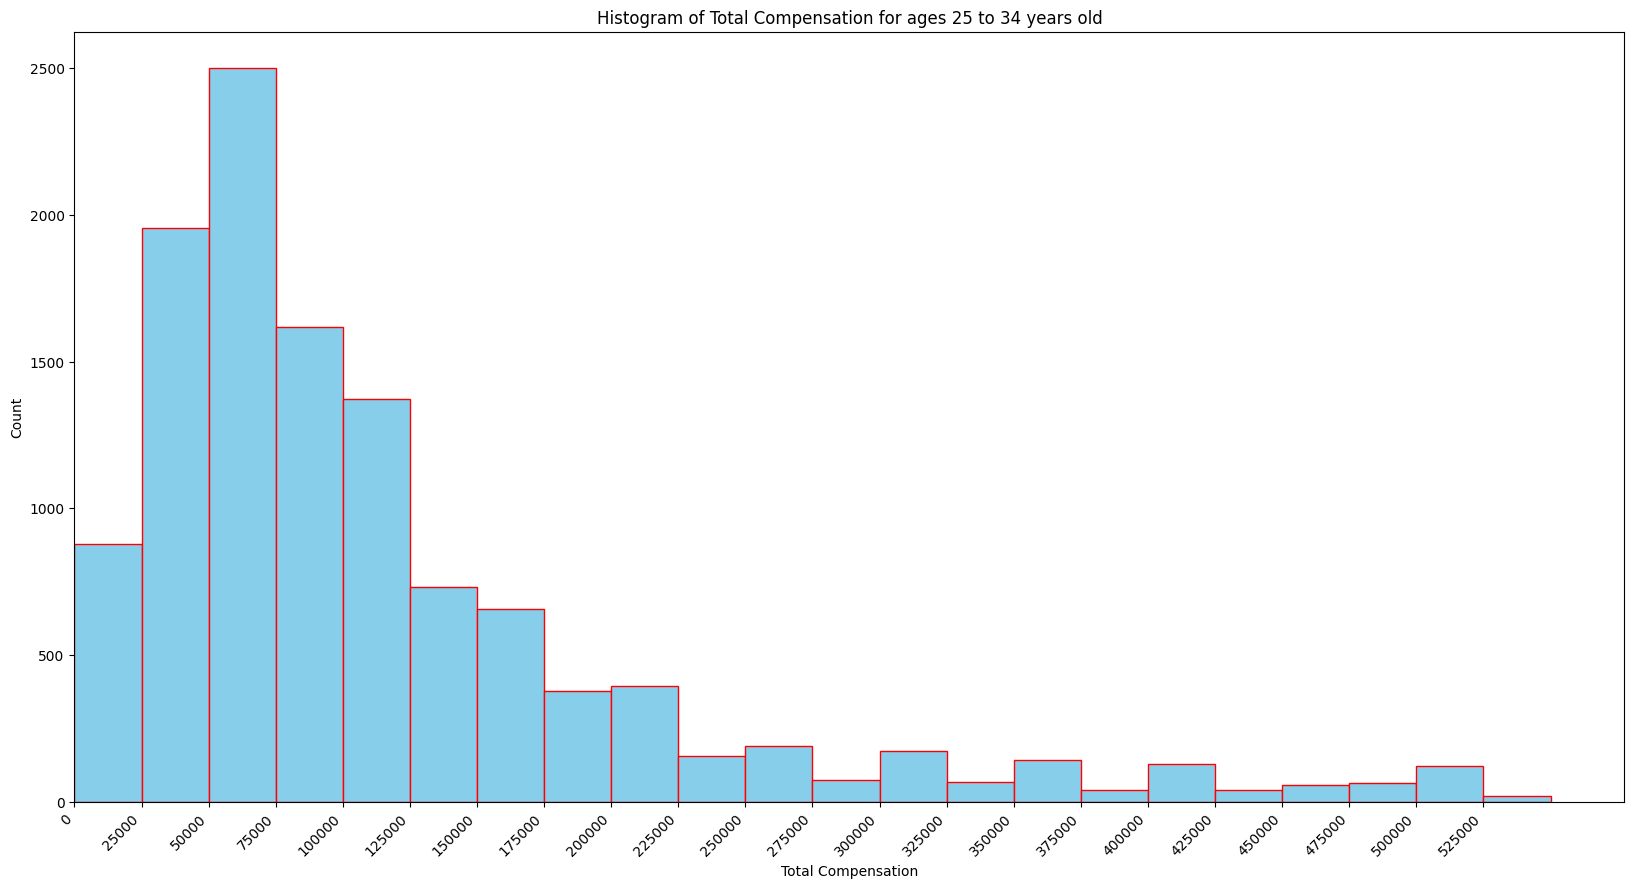

In [19]:
#Histogram for the age range '25-34 years old' with no outliers
df_ct_25_34 = df_ct_no_out[df_ct_no_out['Age']=='25-34 years old']
#plotting the histogram
plt.figure(figsize=(20, 10))
# Using plt.hist to create the histogram
counts, bins, patches = plt.hist(df_ct_25_34['CompTotal'], bins=list(range(0, 575000, 25000)), color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Total Compensation')
plt.ylabel('Count')
plt.title('Histogram of Total Compensation for ages 25 to 34 years old')
plt.xlim(left=0)
plt.show()

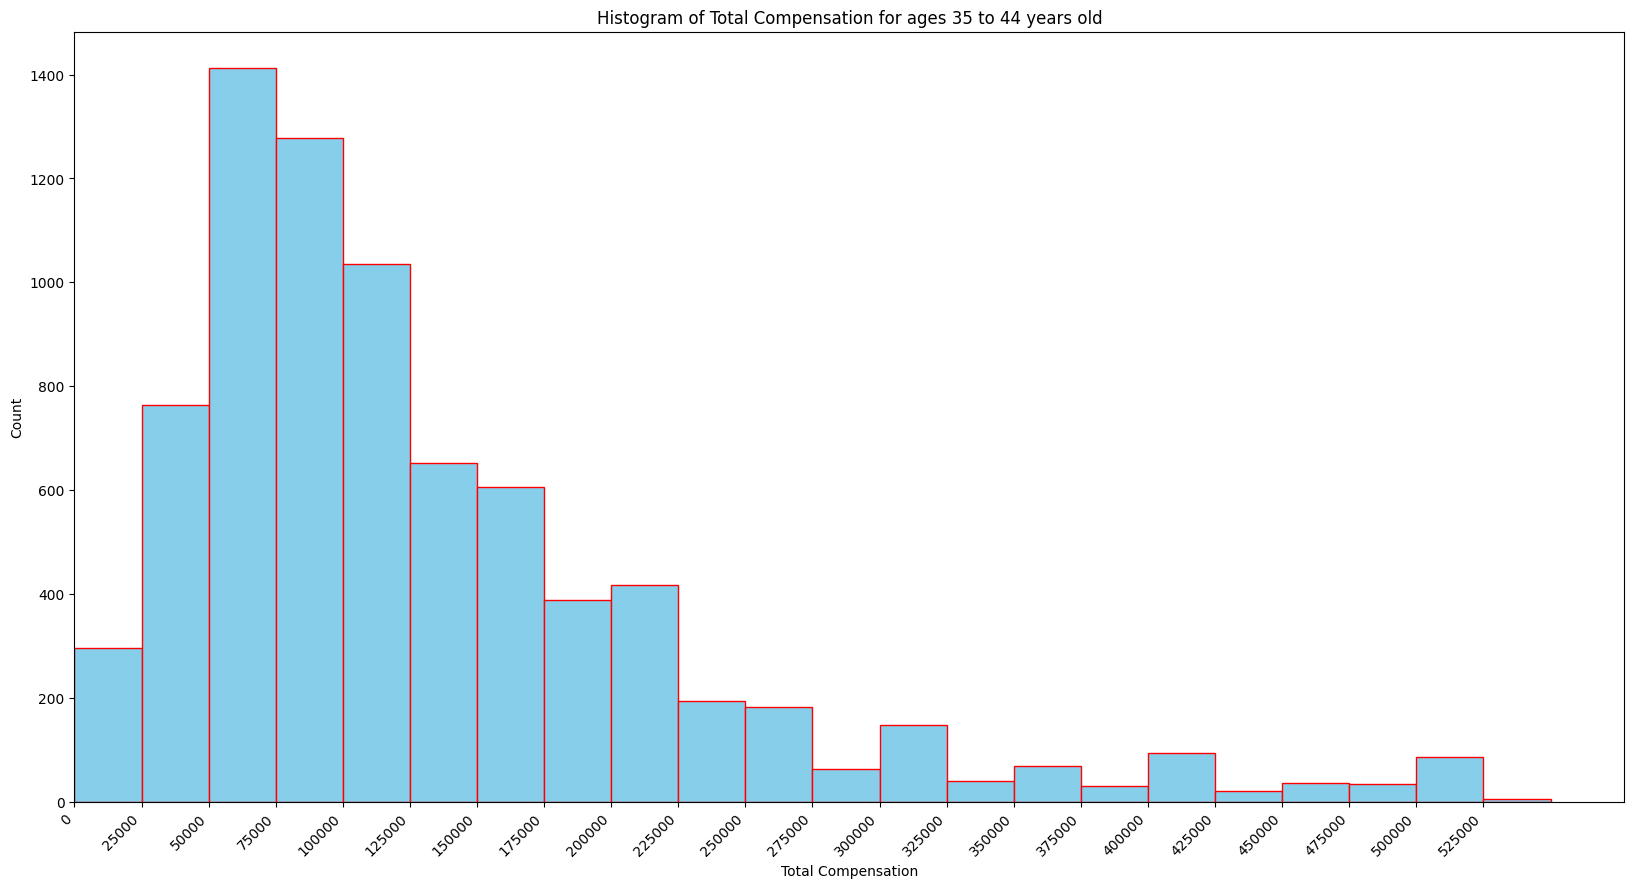

In [20]:
#Histogram for the age range '35-44 years old' with no outliers
df_ct_35_44 = df_ct_no_out[df_ct_no_out['Age']=='35-44 years old']
#plotting the histogram
plt.figure(figsize=(20, 10))
# Using plt.hist to create the histogram
counts, bins, patches = plt.hist(df_ct_35_44['CompTotal'], bins=list(range(0, 575000, 25000)), color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins[:-1], rotation=45, ha='right')
plt.xlabel('Total Compensation')
plt.ylabel('Count')
plt.title('Histogram of Total Compensation for ages 35 to 44 years old')
plt.xlim(left=0)
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [21]:
#let's get a specific dataset for this analysis, with no missing values
QUERY = "SELECT TimeSearching, Age FROM main WHERE TimeSearching IS NOT NULL AND Age IS NOT NULL"
df_tsa = pd.read_sql_query(QUERY, conn)
df_tsa.head()

,TimeSearching,Age
0,30-60 minutes a day,35-44 years old
1,30-60 minutes a day,35-44 years old
2,60-120 minutes a day,45-54 years old
3,15-30 minutes a day,25-34 years old
4,Less than 15 minutes a day,25-34 years old


In [22]:
df_tsa['TimeSearching'].unique()

array(['30-60 minutes a day', '60-120 minutes a day',
       '15-30 minutes a day', 'Less than 15 minutes a day',
       'Over 120 minutes a day'], dtype=object)

+++As TimeSearching is a categorical variable, we shall use bar charts instead of histograms to explore these distributions

In [23]:
#Distribution of TimeSearching for Age = '25-24 years old'
df_tsa_25_34 = df_tsa[df_tsa['Age']=='25-34 years old']['TimeSearching']
df_tsa_25_34_counts = df_tsa_25_34.value_counts().reset_index()
df_tsa_25_34_counts

,TimeSearching,count
0,30-60 minutes a day,4901
1,15-30 minutes a day,3332
2,60-120 minutes a day,2345
3,Less than 15 minutes a day,1047
4,Over 120 minutes a day,978


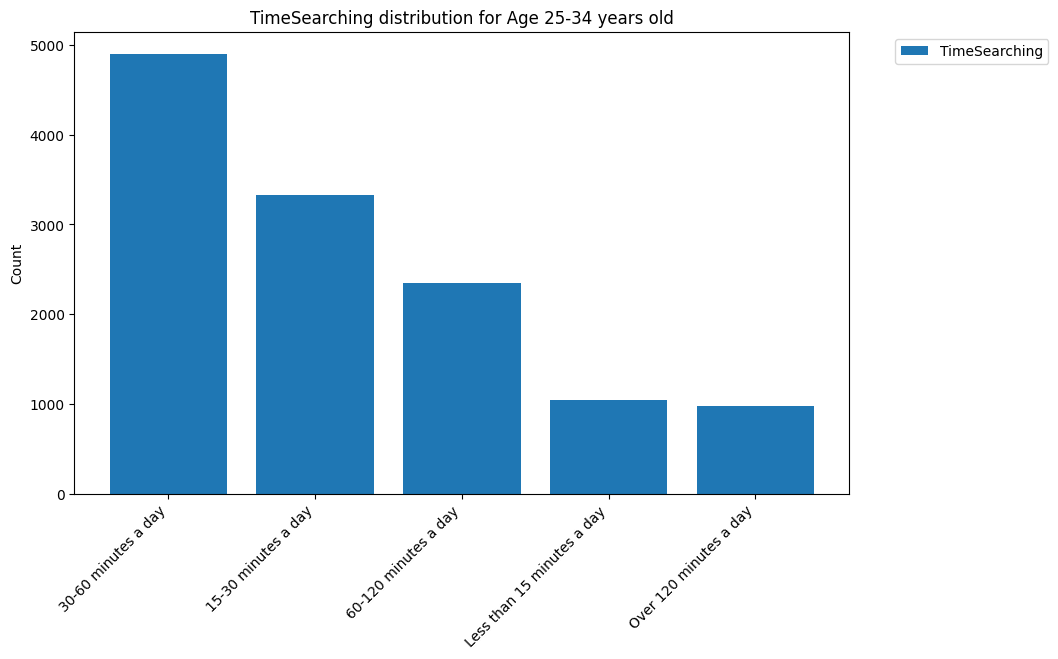

In [24]:
# Create a bar chart
plt.figure(figsize=(10,6))
plt.bar(df_tsa_25_34_counts['TimeSearching'], df_tsa_25_34_counts['count'], label='TimeSearching')

# Formatting
plt.ylabel('Count')
plt.title('TimeSearching distribution for Age 25-34 years old')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.show()

+++We can plot bar charts for the diverse Age groups; but instead,let's plot a stacked bar chart showing all age groups

In [25]:
df_tsa_grouped = df_tsa.groupby(['Age', 'TimeSearching']).value_counts().reset_index()
df_tsa_grouped

,Age,TimeSearching,count
0,18-24 years old,15-30 minutes a day,922
1,18-24 years old,30-60 minutes a day,1614
2,18-24 years old,60-120 minutes a day,996
3,18-24 years old,Less than 15 minutes a day,223
4,18-24 years old,Over 120 minutes a day,420
5,25-34 years old,15-30 minutes a day,3332
6,25-34 years old,30-60 minutes a day,4901
7,25-34 years old,60-120 minutes a day,2345
8,25-34 years old,Less than 15 minutes a day,1047
9,25-34 years old,Over 120 minutes a day,978


In [26]:
# Pivot the data so that TimeSearching categories are rows and Age groups are columns
pivot_df = df_tsa_grouped.pivot(index='TimeSearching', columns='Age', values='count')
pivot_df

Age,18-24 years old,25-34 years old,35-44 years old,45-54 years old,55-64 years old,65 years or older,Prefer not to say,Under 18 years old
TimeSearching,,,,,,,,
15-30 minutes a day,922,3332,2275,888,325,34,11,18
30-60 minutes a day,1614,4901,2924,1096,331,45,12,28
60-120 minutes a day,996,2345,1309,448,143,11,9,14
Less than 15 minutes a day,223,1047,910,350,126,18,8,7
Over 120 minutes a day,420,978,542,173,55,10,8,5


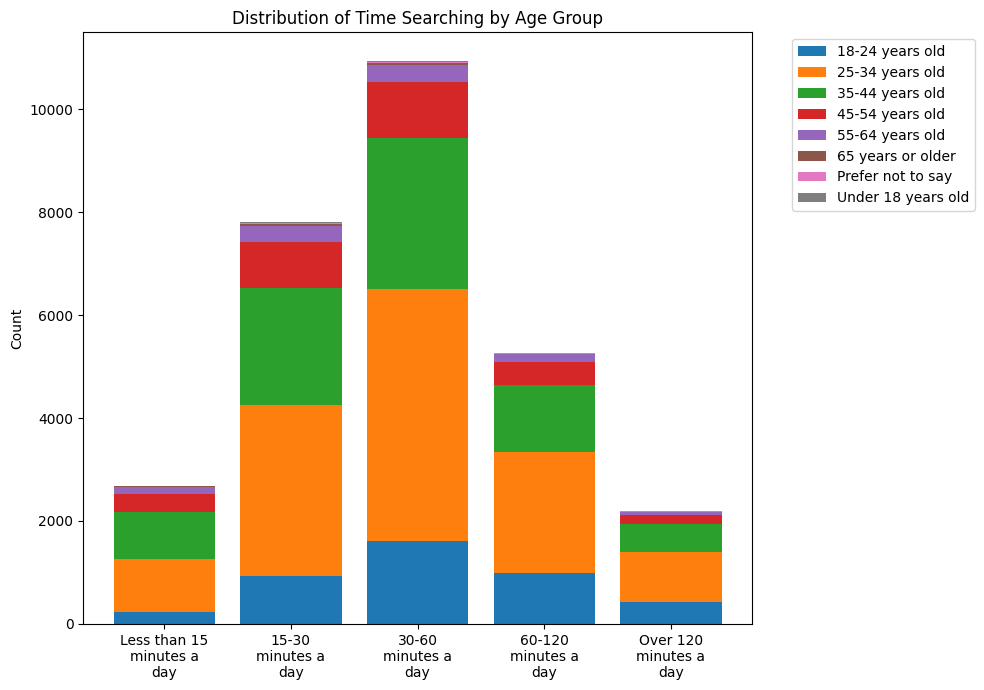

In [27]:
#let's plot the bar chart
# Sort the TimeSearching categories if desired (optional)
pivot_df = pivot_df.loc[['Less than 15 minutes a day', '15-30 minutes a day', '30-60 minutes a day', '60-120 minutes a day', 'Over 120 minutes a day']]

# Wrap x-axis labels (so they appear on multiple lines instead of rotating)
wrapped_labels = [textwrap.fill(label, width=12) for label in pivot_df.index]

# Plot
plt.figure(figsize=(10, 7))
bottom = None

for age in pivot_df.columns:
    plt.bar(wrapped_labels, pivot_df[age], bottom=bottom, label=age)
    bottom = pivot_df[age] if bottom is None else bottom + pivot_df[age]

# Formatting
plt.ylabel('Count')
plt.title('Distribution of Time Searching by Age Group')
plt.xticks(rotation=0, ha='center')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


+++this is a categorical variable, so a histogram does not apply here! We will show a bar chart of the top 5 databases

In [28]:
#let's get a specific dataset for this analysis, with no missing values
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_dwww = pd.read_sql_query(QUERY, conn)
df_dwww.head()

,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB;MySQL;PostgreSQL
3,PostgreSQL;SQLite
4,Cloud Firestore


In [29]:
#We see that the DatabaseWantToWorkWith column is multi-option, and shall be 'exploded' on the individual options in order to do this analysis
df_dwww['DBWWWItem'] = df_dwww['DatabaseWantToWorkWith'].str.split(';').explode('DBWWWItem')
df_dwww.drop('DatabaseWantToWorkWith', axis=1, inplace=True)
df_dwww.rename(columns={'DBWWWItem': 'DatabaseWantToWorkWith'}, inplace=True)
df_dwww.head()


,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB
3,MySQL
4,PostgreSQL


In [30]:
df_dwww_counts = df_dwww.value_counts().head().reset_index()
df_dwww_counts

,DatabaseWantToWorkWith,count
0,PostgreSQL,8080
1,SQLite,4610
2,MySQL,4022
3,MongoDB,3766
4,Redis,3665


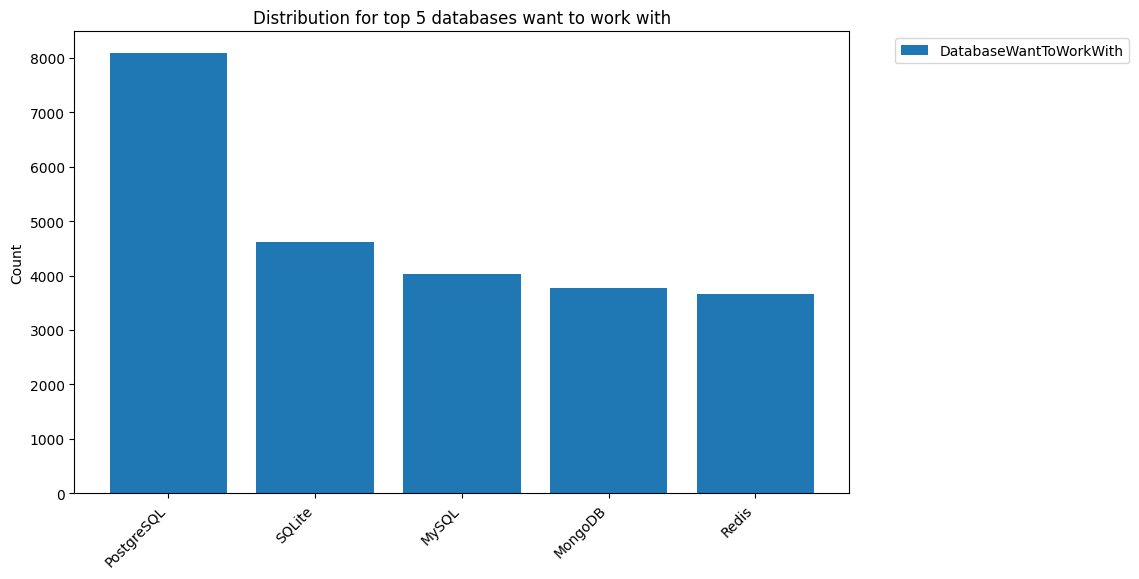

In [31]:
# Create a bar chart
plt.figure(figsize=(10,6))
plt.bar(df_dwww_counts['DatabaseWantToWorkWith'], df_dwww_counts['count'], label='DatabaseWantToWorkWith')

# Formatting
plt.ylabel('Count')
plt.title('Distribution for top 5 databases want to work with')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


+++Again, this is a categorical variable, so a histogram does not apply here! We will show a bar chart with the distribution

In [32]:
#let's get a specific dataset for this analysis, with no missing values
QUERY = "SELECT RemoteWork FROM main WHERE RemoteWork IS NOT NULL"
df_rw = pd.read_sql_query(QUERY, conn)
df_rw.head()

,RemoteWork
0,Remote
1,Remote
2,Remote
3,Remote
4,In-person


In [33]:
df_rw_counts = df_rw.value_counts().reset_index()
df_rw_counts

,RemoteWork,count
0,"Hybrid (some remote, some in-person)",23015
1,Remote,20831
2,In-person,10960


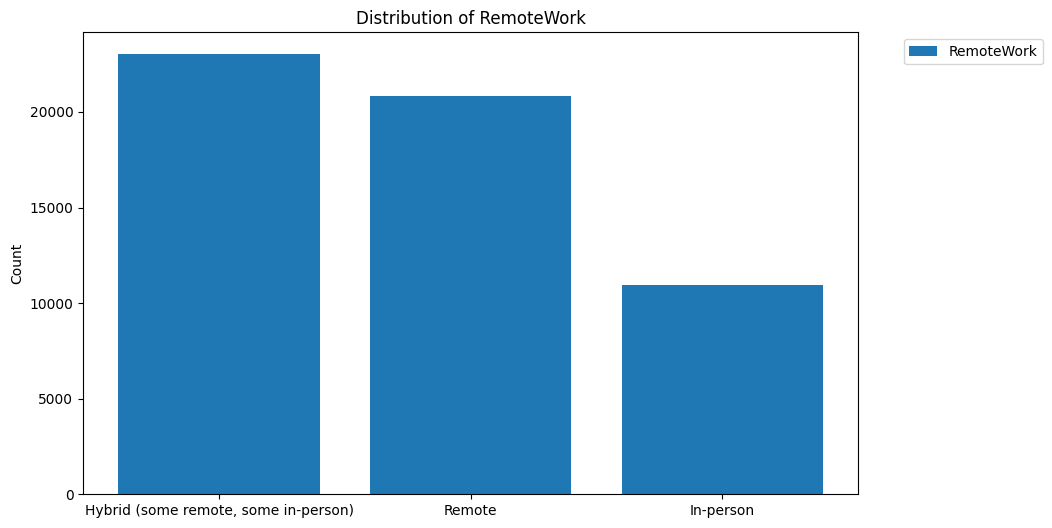

In [34]:
# Create a bar chart
plt.figure(figsize=(10,6))

plt.bar(df_rw_counts['RemoteWork'], df_rw_counts['count'], label='RemoteWork')

# Formatting
plt.ylabel('Count')
plt.title('Distribution of RemoteWork')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0, ha='center')
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


+++We have again the same issue... 'Age' is not a numerical variable, and there is no age group '45-60 years old'; we will use, as an approximation, the age groups '45-54 years old' and '55-64 years old' to do this analysis. We will plot a bar chart of Median CompTotal for these two age groups

In [35]:
#let's get a specific dataset for this analysis, with no missing values
QUERY = "SELECT CompTotal, Age FROM main WHERE CompTotal IS NOT NULL AND Age IS NOT NULL AND (Age=='45-54 years old' OR Age=='55-64 years old')"
df_cta = pd.read_sql_query(QUERY, conn)
df_cta.head()

,CompTotal,Age
0,95000.0,45-54 years old
1,195000.0,45-54 years old
2,54000.0,55-64 years old
3,145000.0,45-54 years old
4,80000.0,55-64 years old


In [36]:
df_cta_grouped = df_cta.groupby('Age').median('CompTotal')
df_cta_grouped

,CompTotal
Age,
45-54 years old,130000.0
55-64 years old,135000.0


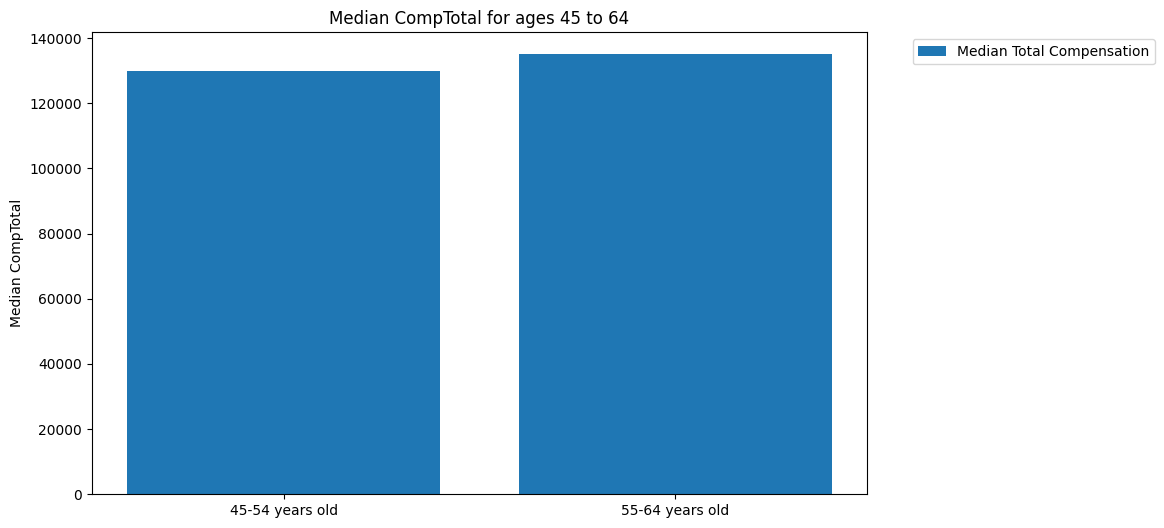

In [11]:
# Create a bar chart
plt.figure(figsize=(10,6))

plt.bar(df_cta_grouped.index, df_cta_grouped['CompTotal'], label='Median Total Compensation')

# Formatting
plt.ylabel('Median CompTotal')
plt.title('Median CompTotal for ages 45 to 64')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0, ha='center')
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [37]:
#let's get a specific dataset for this analysis, with no missing values
QUERY = "SELECT YearsCodePro, JobSat FROM main WHERE YearsCodePro IS NOT NULL AND JobSat IS NOT NULL"
df_ycpjs = pd.read_sql_query(QUERY, conn)
print(df_ycpjs.shape)
df_ycpjs.head()

(28356, 2)


,YearsCodePro,JobSat
0,12,8.0
1,27,5.0
2,10,10.0
3,Less than 1 year,6.0
4,18,9.0


In [38]:
df_ycpjs['JobSat'].value_counts()

JobSat
8.0     7325
7.0     6243
6.0     3651
9.0     3557
10.0    2196
5.0     1869
3.0     1141
4.0     1097
2.0      736
0.0      284
1.0      257
Name: count, dtype: int64

In [39]:
df_ycpjs['YearsCodePro'].value_counts()

YearsCodePro
3                     2261
2                     2153
5                     2016
10                    1918
4                     1866
6                     1725
8                     1588
7                     1533
1                     1173
12                    1111
9                      973
15                     935
20                     819
11                     806
Less than 1 year       780
13                     703
14                     629
16                     577
18                     526
25                     505
17                     481
24                     343
30                     318
19                     312
22                     275
23                     258
26                     243
21                     216
27                     212
28                     170
35                     122
29                     100
32                     100
40                      90
33                      72
34                      72
36             

In [40]:
#let's convert the YearsCodePro column to float; 'Less than 1 year' will be converted to 0.5 and 'More than 50 years' to 55.0
df_ycpjs['YearsCodePro'] = df_ycpjs['YearsCodePro'].replace('Less than 1 year', '0.5')
df_ycpjs['YearsCodePro'] = df_ycpjs['YearsCodePro'].replace('More than 50 years', '55')
df_ycpjs['YearsCodePro'] = df_ycpjs['YearsCodePro'].astype(float)
df_ycpjs.head()

,YearsCodePro,JobSat
0,12.0,8.0
1,27.0,5.0
2,10.0,10.0
3,0.5,6.0
4,18.0,9.0


+++Histograms are univariable, so let's plot histograms of JobSat for different ranges of YearsCodePro

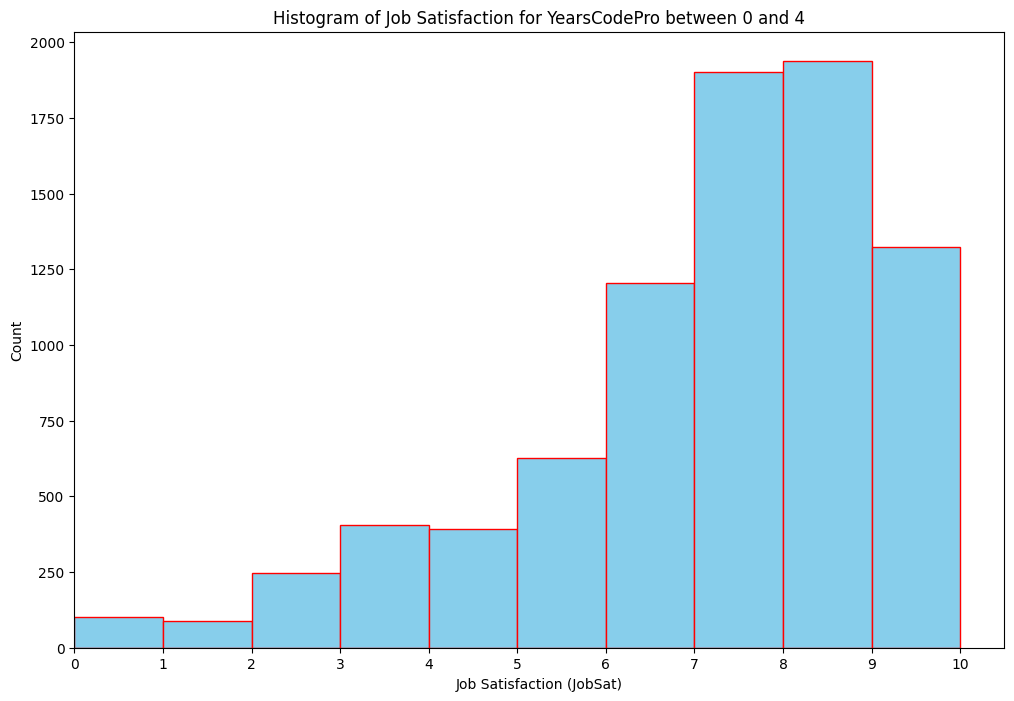

In [41]:
#JobSat distribution for YearsCodePro between 0-4 years
df_ycpjs_0_4 = df_ycpjs[df_ycpjs['YearsCodePro']<=4.0]
#plotting the histogram
plt.figure(figsize=(12, 8))
# Using plt.hist to create the histogram
counts, bins, patches = plt.hist(df_ycpjs_0_4['JobSat'], bins=10, color='skyblue', edgecolor='red')
# Set x-axis ticks at the center of bins
plt.xticks(bins, rotation=0, ha='center')
plt.xlabel('Job Satisfaction (JobSat)')
plt.ylabel('Count')
plt.title('Histogram of Job Satisfaction for YearsCodePro between 0 and 4')
plt.xlim(left=0)
plt.show()

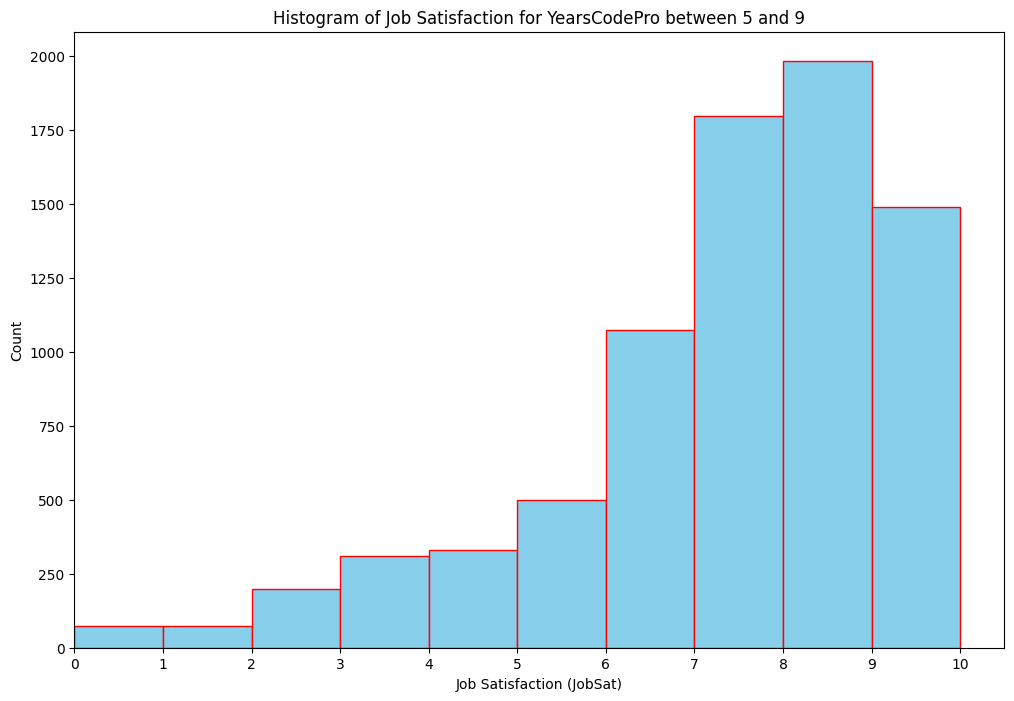

In [42]:
#JobSat distribution for YearsCodePro between 5 and 9 years
df_ycpjs_5_9 = df_ycpjs[(df_ycpjs['YearsCodePro'] >= 5.0) & (df_ycpjs['YearsCodePro'] <= 9.0)]
#plotting the histogram
plt.figure(figsize=(12, 8))
# Using plt.hist to create the histogram
counts, bins, patches = plt.hist(df_ycpjs_5_9['JobSat'], bins=10, color='skyblue', edgecolor='red') 
# Set x-axis ticks at the left edges of bins
plt.xticks(bins, rotation=0, ha='center')
plt.xlabel('Job Satisfaction (JobSat)')
plt.ylabel('Count')
plt.title('Histogram of Job Satisfaction for YearsCodePro between 5 and 9')
plt.xlim(left=0)
plt.show()

+++We can plot histograms on the same way for other ranges of Year

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [43]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
